In [36]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [37]:
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float
    equation: str
    equation_type: Literal["real", "complex"]
    determinant: float

In [38]:
def show_equation(state: QuadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]

    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {"equation": equation}

In [39]:
def show_equation_type(state: QuadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]

    determinant = b ** 2 - 4 * a * c
    if determinant >= 0:
        equation_type = "real"
    else:
        equation_type = "complex"

    return {"equation_type": equation_type}

In [40]:
def calculate_determinant(state: QuadraticState):
    a = state["a"]
    b = state["b"]
    c = state["c"]

    determinant = b ** 2 - 4 * a * c
    return {"determinant": determinant}

In [41]:
def calculate_real_roots(state: QuadraticState):
    a = state["a"]
    b = state["b"]
    determinant = state["determinant"]

    root1 = (-b + (determinant ** 0.5)) / (2 * a)
    root2 = (-b - (determinant ** 0.5)) / (2 * a)

    result = f"the two real roots are {root1}, {root2}"
    return {"result": result}

In [42]:
def calculate_repeated_roots(state: QuadraticState):
    a = state["a"]
    b = state["b"]

    roots = -b / (2 * a)
    result = f"the repeated roots are {roots}, {roots}"
    return {"result": result}

In [43]:
def no_real_roots(state: QuadraticState):
    result = "No real roots"
    return {"result": result}

In [44]:
def check_condition(state: QuadraticState) -> Literal["calculate_real_roots", "calculate_repeated_roots", "no_real_roots"]:
    determinant = state["determinant"]
    if determinant > 0:
        return "calculate_real_roots"
    elif determinant == 0:
        return "calculate_repeated_roots"
    else:
        return "no_real_roots"

In [45]:
graph = StateGraph(QuadraticState)

In [46]:
graph.add_node("show_equation", show_equation)
graph.add_node("show_equation_type", show_equation_type)
graph.add_node("calculate_determinant", calculate_determinant)
graph.add_node("calculate_real_roots", calculate_real_roots)
graph.add_node("calculate_repeated_roots", calculate_repeated_roots)
graph.add_node("no_real_roots", no_real_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "show_equation_type")
graph.add_edge("show_equation_type", "calculate_determinant")
graph.add_conditional_edges("calculate_determinant", check_condition)
graph.add_edge("calculate_real_roots", END)
graph.add_edge("calculate_repeated_roots", END)
graph.add_edge("no_real_roots", END)

In [ ]:
workflow = graph.compile()

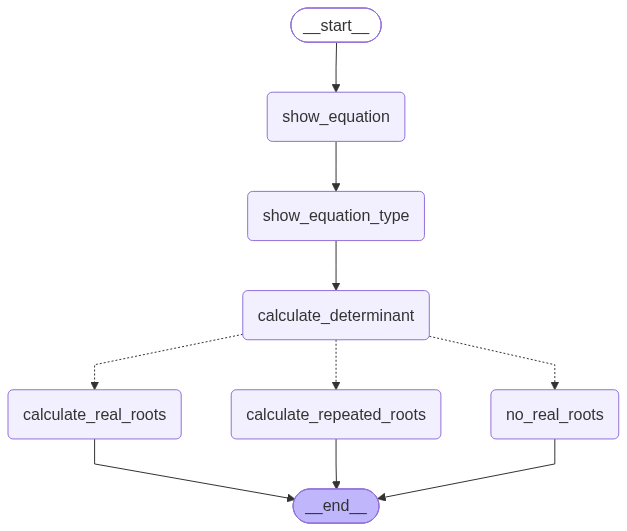

In [49]:
workflow

In [51]:
initial_state = {
    "a": 1,
    "b": -3,
    "c": 2,
    "equation": "",
    "equation_type": "real",
    "determinant": 0,
}

final_state = workflow.invoke(initial_state)

In [52]:
print(final_state)

{'a': 1, 'b': -3, 'c': 2, 'equation': '1x^2 + -3x + 2 = 0', 'equation_type': 'real', 'determinant': 1}
